# 🍓 Strawberry Plant Disease Detection
### CNN · VGG16 · MobileNetV2 · ResNet50 — Transfer Learning Comparison

Which model gives best accuarcy for prediction of diseases.

At the bottom of code upload strawberry disease image from your computer and check the disease.


**7 Disease Classes:**  
`angular_leaf_spot` · `anthracnose_fruit_rot` · `blossom_blight` · `gray_mold` · `leaf_spot` · `powdery_mildew_fruit` · `powdery_mildew_leaf`

---


## Imports

In [16]:
import os, shutil, random, glob, itertools, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

print("✅ TensorFlow version:", tf.__version__)
print("✅ GPU available:", tf.config.list_physical_devices('GPU'))


✅ TensorFlow version: 2.19.0
✅ GPU available: []


## 📂 Step 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## ⚙️ Step 3 — Configuration

> **Only edit this cell.** Everything else reads from these variables.


In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────
RAW_DATA_DIR    = "/content/drive/MyDrive/disease datasets"   # raw class folders
BASE_DIR        = "/content/drive/MyDrive/disease datasets"   # where splits are created
MODEL_SAVE_PATH = "/content/drive/MyDrive/strawberry_vgg16.keras"

# ── Training hyperparameters ───────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 10
EPOCHS_CNN = 7
EPOCHS_TL  = 5

# ── Class names  ────────────────────
CLASSES = [
    "angular_leaf_spot",
    "anthracnose_fruit_rot",
    "blossom_blight",
    "gray_mold",
    "leaf_spot",
    "powdery_mildew_fruit",
    "powdery_mildew_leaf",
]

print("✅ Config ready. Classes:", CLASSES)


✅ Config ready. Classes: ['angular_leaf_spot', 'anthracnose_fruit_rot', 'blossom_blight', 'gray_mold', 'leaf_spot', 'powdery_mildew_fruit', 'powdery_mildew_leaf']


## Organising Dataset into Train / Val / Test

Splits the raw image folders into:
- **60 %** → `train/`
- **20 %** → `val/`
- **20 %** → `test/`



In [17]:
def split_dataset(raw_dir, base_dir, train_ratio=0.6, val_ratio=0.2):
    """Move images from flat class folders → train/val/test sub-folders."""
    if os.path.isdir(os.path.join(base_dir, "train", CLASSES[0])):
        print("✅ Dataset already split — skipping.")
        return

    for split in ["train", "val", "test"]:
        for cls in CLASSES:
            os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

    os.chdir(raw_dir)
    for cls in CLASSES:
        files = glob.glob(f"{cls}*")
        random.shuffle(files)
        n_train = int(len(files) * train_ratio)
        n_val   = int(len(files) * val_ratio)

        for f in files[:n_train]:
            shutil.move(f, os.path.join(base_dir, "train", cls))
        for f in files[n_train : n_train + n_val]:
            shutil.move(f, os.path.join(base_dir, "val", cls))
        for f in files[n_train + n_val:]:
            shutil.move(f, os.path.join(base_dir, "test", cls))

        print(f"  {cls}: {n_train} train | {n_val} val | {len(files)-n_train-n_val} test")

    print("\n✅ Dataset split complete!")

split_dataset(RAW_DATA_DIR, BASE_DIR)

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")


✅ Dataset already split — skipping.


## Data Generators

**Training generator** — includes **data augmentation** (rotations, flips, zoom)
to artificially increase dataset variety and reduce overfitting.

**Val / Test generators** — only preprocessing, no augmentation
(we want to evaluate on real, unmodified images).


In [23]:
# Preprocessing functions — each model needs its own
vgg_preprocess       = tf.keras.applications.vgg16.preprocess_input
mobilenet_preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
resnet_preprocess    = tf.keras.applications.resnet50.preprocess_input


def make_loader(datagen, directory, shuffle=False):
    return datagen.flow_from_directory(
        directory=directory,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        classes=CLASSES,
        shuffle=shuffle,
    )

def get_batches(preprocess_fn, augment=True):
    """Return train/val/test loaders for any preprocessing function."""
    if augment:
        train_gen = ImageDataGenerator(
            preprocessing_function=preprocess_fn,
            rotation_range=20,
            zoom_range=0.15,
            horizontal_flip=True,
            width_shift_range=0.1,
            height_shift_range=0.1,
        )
    else:
        train_gen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)
    return (
        make_loader(train_gen, TRAIN_DIR, shuffle=True),
        make_loader(eval_datagen,  VAL_DIR),
        make_loader(eval_datagen,  TEST_DIR),
    )

# Default loaders — VGG16 preprocessing with augmentation
train_batches, val_batches, test_batches = get_batches(vgg_preprocess, augment=True)

print(f"Train  : {train_batches.samples:>4} images")
print(f"Val    : {val_batches.samples:>4} images")
print(f"Test   : {test_batches.samples:>4} images")


Found 1450 images belonging to 7 classes.
Found 264 images belonging to 7 classes.
Found 549 images belonging to 7 classes.
Train  : 1450 images
Val    :  264 images
Test   :  549 images


## Visualise Sample Images

Let's check the data looks correct before training.


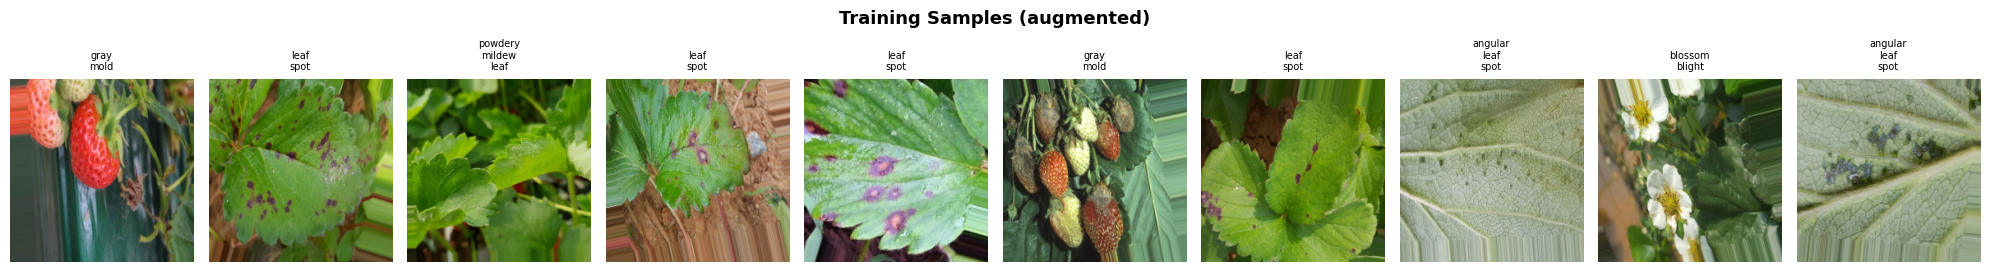

In [24]:
def show_samples(batches, n=10, title="Sample Images"):
    imgs, labels = next(batches)
    class_idx = {v: k for k, v in batches.class_indices.items()}

    fig, axes = plt.subplots(1, n, figsize=(20, 3))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for i, (img, ax) in enumerate(zip(imgs[:n], axes)):
        # Undo VGG16 preprocessing to display correctly
        display = img + [103.939, 116.779, 123.68]
        display = np.clip(display / 255.0, 0, 1)[..., ::-1]  # BGR → RGB
        ax.imshow(display)
        ax.set_title(class_idx[np.argmax(labels[i])].replace("_", "\n"), fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_batches, title="Training Samples (augmented)")


## Helper Functions

In [25]:
def plot_history(history, title="Training History"):
    """Side-by-side accuracy and loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for ax, metric, ylabel in [
        (ax1, "accuracy", "Accuracy"),
        (ax2, "loss",     "Loss"),
    ]:
        ax.plot(history.history[metric],           label="Train",      linewidth=2)
        ax.plot(history.history[f"val_{metric}"],  label="Validation", linewidth=2, linestyle="--")
        ax.set_title(ylabel)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    """Plots a formatted confusion matrix. Set normalize=True for percentages."""
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        fmt, title = ".2f", title + " (Normalized)"
    else:
        fmt = "d"

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title, fontsize=13, fontweight="bold")
    plt.colorbar()

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right", fontsize=9)
    plt.yticks(ticks, class_names, fontsize=9)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        val = f"{cm[i,j]:{fmt}}"
        plt.text(j, i, val, ha="center", va="center", fontsize=8,
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label", fontsize=11)
    plt.xlabel("Predicted label", fontsize=11)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, class_names, title="Model"):
    """Full evaluation: classification report + confusion matrices."""
    # Use a fresh loader with shuffle=False so class order is deterministic
    test_eval = make_loader(eval_datagen, TEST_DIR, shuffle=False)
    preds  = model.predict(test_eval, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_eval.classes

    print(f"\n{'='*60}")
    print(f"  {title} — Classification Report")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, class_names, title=f"{title} — Confusion Matrix")
    plot_confusion_matrix(cm, class_names, title=f"{title} — Confusion Matrix", normalize=True)


print("✅ Helper functions defined.")


✅ Helper functions defined.


## Model A : Custom CNN (Baseline)

A simple 2-block CNN built from scratch.
limited accuracy on small datasets.

**Architecture:**
```
Input(224×224×3)
  → Conv2D(32) → MaxPool
  → Conv2D(64) → MaxPool
  → Dropout(0.3)
  → Dense(128, relu)
  → Dense(7, softmax)
```


In [26]:
def build_custom_cnn(num_classes=7):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation="relu", padding="same",
                      input_shape=(224, 224, 3)),
        layers.MaxPool2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.MaxPool2D(2, 2),

        # Regularisation
        layers.Dropout(0.3),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ], name="CustomCNN")
    return model

cnn_model = build_custom_cnn()
cnn_model.summary()


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,710,535 (98.08 MB)

 Trainable params: 25,710,535 (98.08 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=3,
    restore_best_weights=True, verbose=1
)

print("Training Custom CNN...\n")
cnn_history = cnn_model.fit(
    train_batches,
    epochs=EPOCHS_CNN,
    validation_data=val_batches,
    callbacks=[early_stop],
    verbose=1,
)


Training Custom CNN...

Epoch 1/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 530s 4s/step - accuracy: 0.5290 - loss: 20.4329 - val_accuracy: 0.5833 - val_loss: 3.3311
Epoch 2/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.6345 - loss: 1.5708 - val_accuracy: 0.6364 - val_loss: 1.0243
Epoch 3/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.6800 - loss: 0.9996 - val_accuracy: 0.8523 - val_loss: 0.6467
Epoch 4/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.7310 - loss: 0.8772 - val_accuracy: 0.8447 - val_loss: 0.7689
Epoch 5/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.7772 - loss: 0.7691 - val_accuracy: 0.8295 - val_loss: 0.8558
Epoch 6/7
145/145 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.7772 - loss: 0.7383 - val_accuracy: 0.8826 - val_loss: 0.7378
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


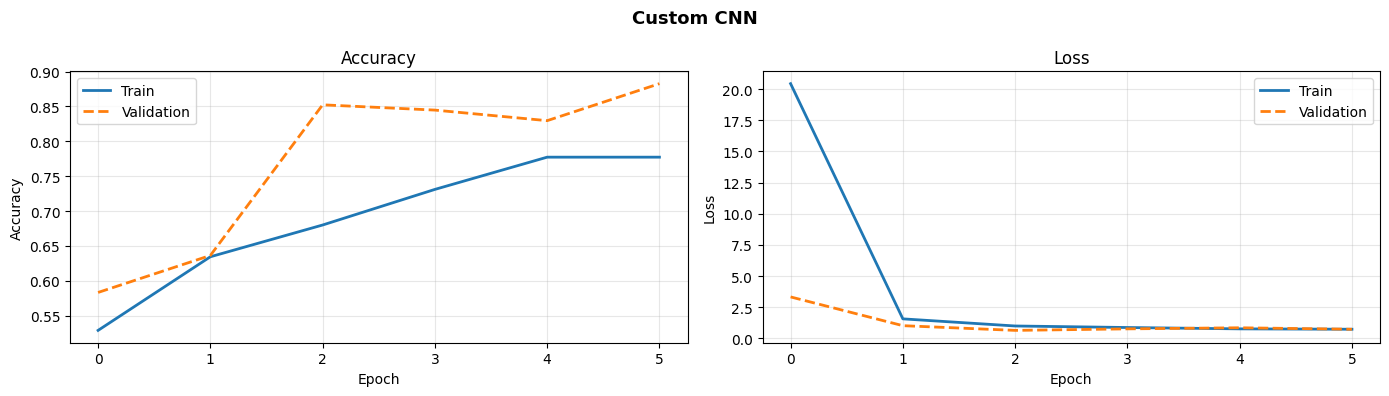

Found 549 images belonging to 7 classes.

  Custom CNN — Classification Report
                       precision    recall  f1-score   support

    angular_leaf_spot      0.286     0.027     0.050       147
anthracnose_fruit_rot      0.000     0.000     0.000        33
       blossom_blight      0.316     0.871     0.464        62
            gray_mold      0.000     0.000     0.000       145
            leaf_spot      0.500     0.068     0.120       162
 powdery_mildew_fruit      0.000     0.000     0.000         0
  powdery_mildew_leaf      0.000     0.000     0.000         0

             accuracy                          0.126       549
            macro avg      0.157     0.138     0.090       549
         weighted avg      0.260     0.126     0.101       549



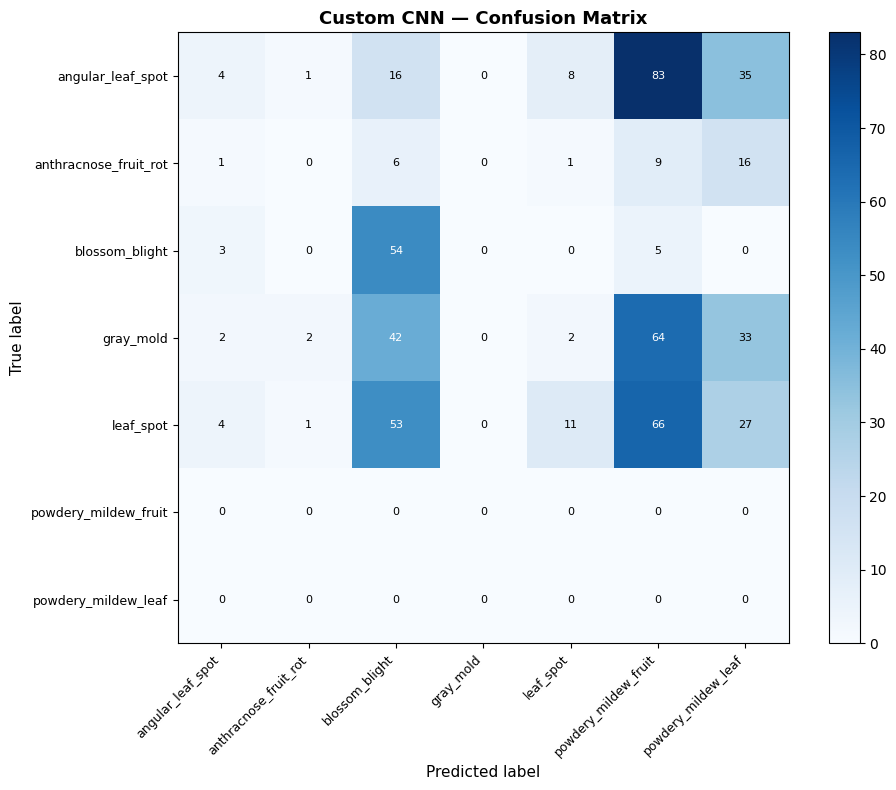

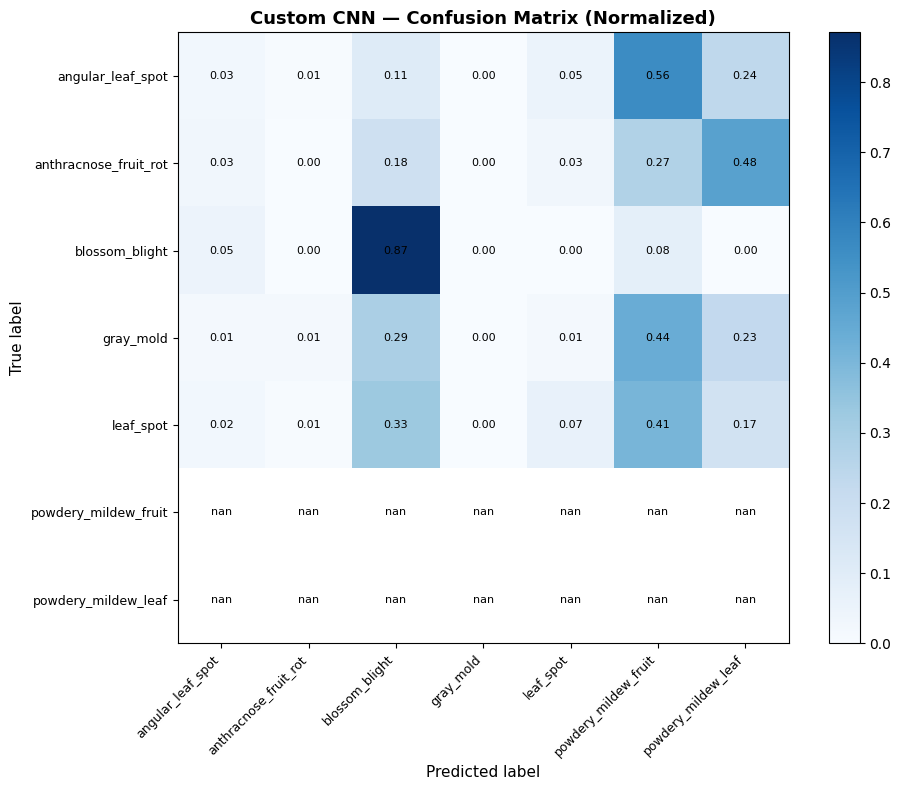

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

plot_history(cnn_history, title="Custom CNN")
evaluate_model(cnn_model, CLASSES, title="Custom CNN")


## Model B : Transfer Learning with VGG16

**Why Transfer Learning?**
VGG16 was trained on 1.2 million ImageNet images. It already knows how to detect
edges, textures, shapes, and complex patterns. We have reused those learned features
and only train the final classification layer for our 7 disease classes.





In [28]:
def build_vgg16_model(num_classes=7):
    # include_top=False → removes VGG16's own 1000-class head
    base = tf.keras.applications.VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3),
    )
    base.trainable = False   # freeze all VGG16 weights

    model = models.Sequential([
        base,
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ], name="VGG16_TransferLearning")
    return model

vgg_model = build_vgg16_model()
vgg_model.summary()

# Check: only the Dense layers should be trainable
trainable = sum(np.prod(w.shape) for w in vgg_model.trainable_weights)
total     = sum(np.prod(w.shape) for w in vgg_model.weights)
print(f"\nTrainable params : {trainable:,}")
print(f"Frozen params    : {total - trainable:,}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,271 (80.64 MB)

 Trainable params: 6,424,583 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Trainable params : 6,424,583
Frozen params    : 14,714,688


In [29]:
vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_vgg = callbacks.EarlyStopping(
    monitor="val_loss", patience=3,
    restore_best_weights=True, verbose=1
)
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, verbose=1
)

print("Training VGG16 Transfer Learning model...\n")
vgg_history = vgg_model.fit(
    train_batches,
    epochs=EPOCHS_TL,
    validation_data=val_batches,
    callbacks=[early_stop_vgg, lr_scheduler],
    verbose=1,
)


Training VGG16 Transfer Learning model...

Epoch 1/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 718s 5s/step - accuracy: 0.6945 - loss: 4.1723 - val_accuracy: 0.8674 - val_loss: 1.2371 - learning_rate: 1.0000e-04
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 708s 5s/step - accuracy: 0.8641 - loss: 1.1545 - val_accuracy: 0.9167 - val_loss: 0.6194 - learning_rate: 1.0000e-04
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 699s 5s/step - accuracy: 0.8848 - loss: 0.6986 - val_accuracy: 0.9318 - val_loss: 0.6021 - learning_rate: 1.0000e-04
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 683s 5s/step - accuracy: 0.9145 - loss: 0.4807 - val_accuracy: 0.9356 - val_loss: 0.4556 - learning_rate: 1.0000e-04
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 676s 5s/step - accuracy: 0.9214 - loss: 0.3919 - val_accuracy: 0.9470 - val_loss: 0.3400 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 5.


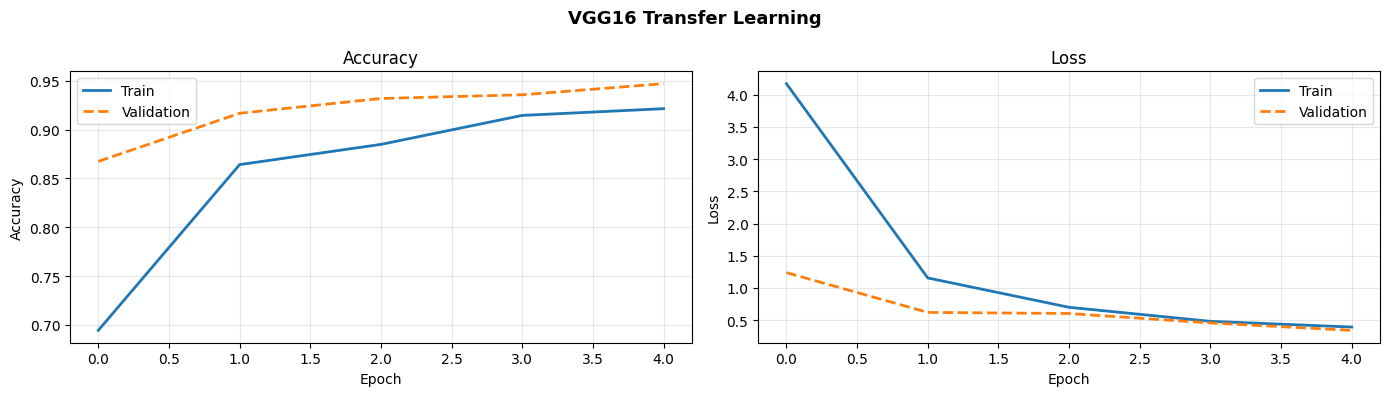

Found 549 images belonging to 7 classes.

  VGG16 Transfer Learning — Classification Report
                       precision    recall  f1-score   support

    angular_leaf_spot      0.793     0.966     0.871       147
anthracnose_fruit_rot      0.714     0.455     0.556        33
       blossom_blight      1.000     0.984     0.992        62
            gray_mold      0.840     0.979     0.904       145
            leaf_spot      0.990     0.642     0.779       162
 powdery_mildew_fruit      0.000     0.000     0.000         0
  powdery_mildew_leaf      0.000     0.000     0.000         0

             accuracy                          0.845       549
            macro avg      0.620     0.575     0.586       549
         weighted avg      0.882     0.845     0.847       549



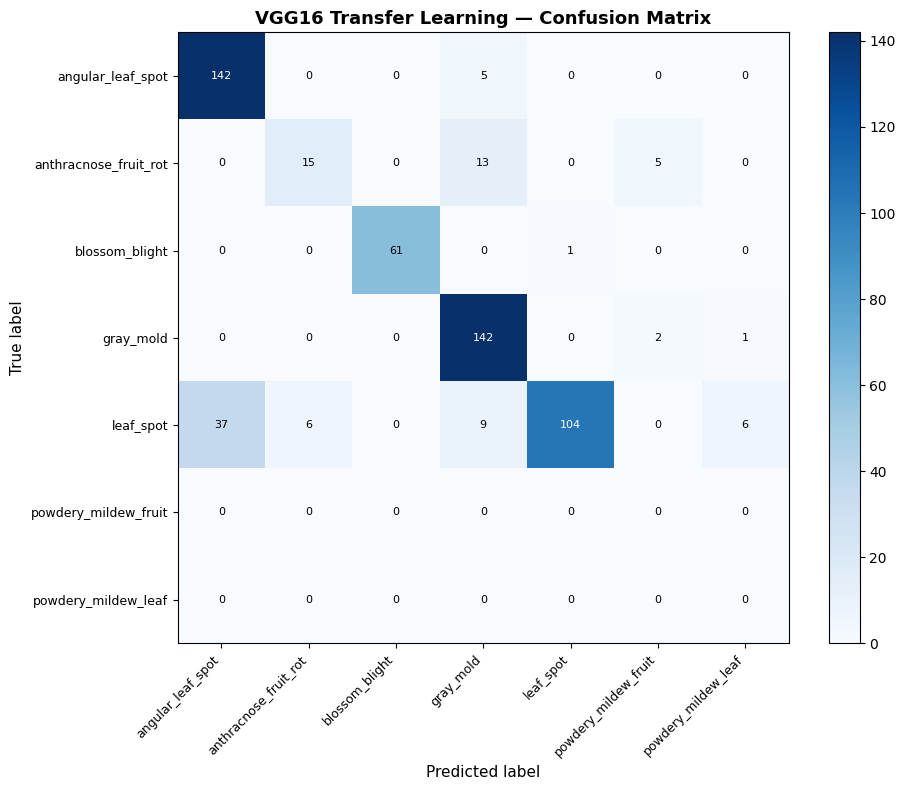

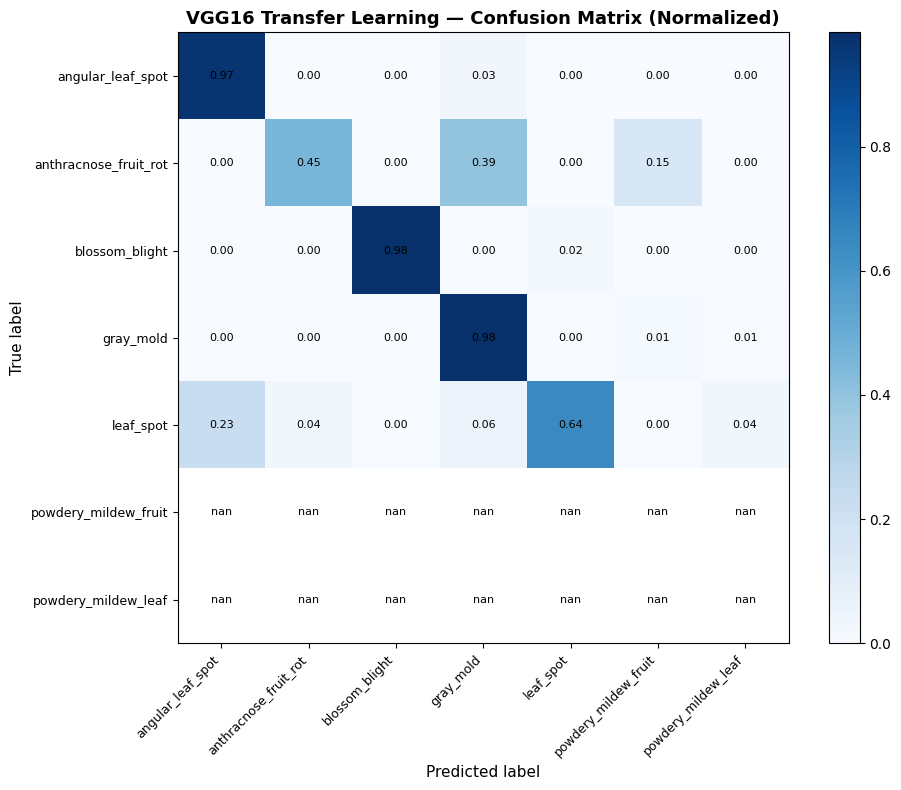

In [30]:
plot_history(vgg_history, title="VGG16 Transfer Learning")
evaluate_model(vgg_model, CLASSES, title="VGG16 Transfer Learning")


---
## Model C : MobileNetV2 Transfer Learning

MobileNetV2 is a **lightweight, fast model** designed for efficiency.



In [31]:
# Reload batches with MobileNetV2 preprocessing
train_batches, val_batches, test_batches = get_batches(mobilenet_preprocess, augment=True)

def build_mobilenet_model(num_classes=7):
    base = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,      # remove original 1000-class head
        weights="imagenet"
    )
    base.trainable = False      # freeze all base layers

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),  # better than Flatten for MobileNetV2
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ], name="MobileNetV2_TransferLearning")
    return model

mobilenet_model = build_mobilenet_model()
mobilenet_model.summary()

trainable = sum(np.prod(w.shape) for w in mobilenet_model.trainable_weights)
print(f"\nTrainable params: {trainable:,}")


Found 1450 images belonging to 7 classes.
Found 264 images belonging to 7 classes.
Found 549 images belonging to 7 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params: 164,871


In [32]:
mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_mob = callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
)
lr_mob = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, verbose=1
)

print("Training MobileNetV2...\n")
mobilenet_history = mobilenet_model.fit(
    train_batches,
    epochs=EPOCHS_TL,
    validation_data=val_batches,
    callbacks=[early_stop_mob, lr_mob],
    verbose=1,
)


Training MobileNetV2...

Epoch 1/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 65s 417ms/step - accuracy: 0.5938 - loss: 1.1874 - val_accuracy: 0.8371 - val_loss: 0.6087 - learning_rate: 1.0000e-04
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 78s 393ms/step - accuracy: 0.8448 - loss: 0.4975 - val_accuracy: 0.8561 - val_loss: 0.4209 - learning_rate: 1.0000e-04
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 56s 386ms/step - accuracy: 0.8897 - loss: 0.3381 - val_accuracy: 0.9053 - val_loss: 0.3048 - learning_rate: 1.0000e-04
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 54s 370ms/step - accuracy: 0.9069 - loss: 0.2786 - val_accuracy: 0.9167 - val_loss: 0.2653 - learning_rate: 1.0000e-04
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 57s 395ms/step - accuracy: 0.9241 - loss: 0.2380 - val_accuracy: 0.9129 - val_loss: 0.2507 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 5.


In [37]:
def evaluate_model(model, class_names, title="Model", preprocess_fn=None):
    """Full evaluation: classification report + confusion matrices."""
    # 1. Define generator on the fly to fix NameError and use correct preprocessing
    eval_gen = ImageDataGenerator(preprocessing_function=preprocess_fn)
    test_eval = make_loader(eval_gen, TEST_DIR, shuffle=False)

    preds  = model.predict(test_eval, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_eval.classes

    print(f"\n{'='*60}")
    print(f"  {title} — Classification Report")
    print(f"{'='*60}")

    # 2. Fix ValueError by adding labels=np.arange(len(class_names))
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        labels=np.arange(len(class_names)),
        digits=3
    ))

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    plot_confusion_matrix(cm, class_names, title=f"{title} — Confusion Matrix")

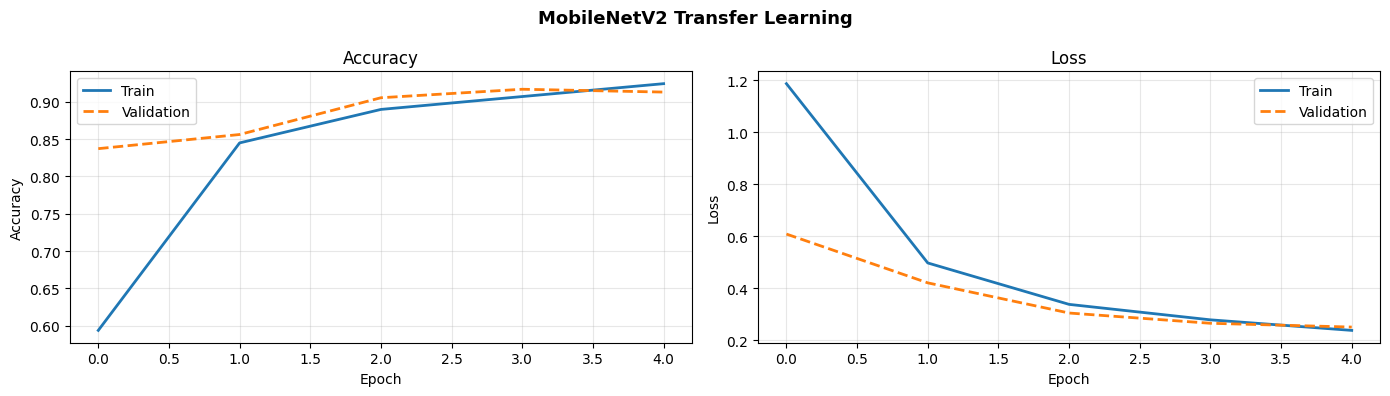

Found 549 images belonging to 7 classes.

  MobileNetV2 — Classification Report
                       precision    recall  f1-score   support

    angular_leaf_spot      0.910     0.898     0.904       147
anthracnose_fruit_rot      0.944     0.515     0.667        33
       blossom_blight      0.969     1.000     0.984        62
            gray_mold      0.882     0.979     0.928       145
            leaf_spot      0.933     0.864     0.897       162
 powdery_mildew_fruit      0.000     0.000     0.000         0
  powdery_mildew_leaf      0.000     0.000     0.000         0

             accuracy                          0.898       549
            macro avg      0.663     0.608     0.626       549
         weighted avg      0.918     0.898     0.903       549



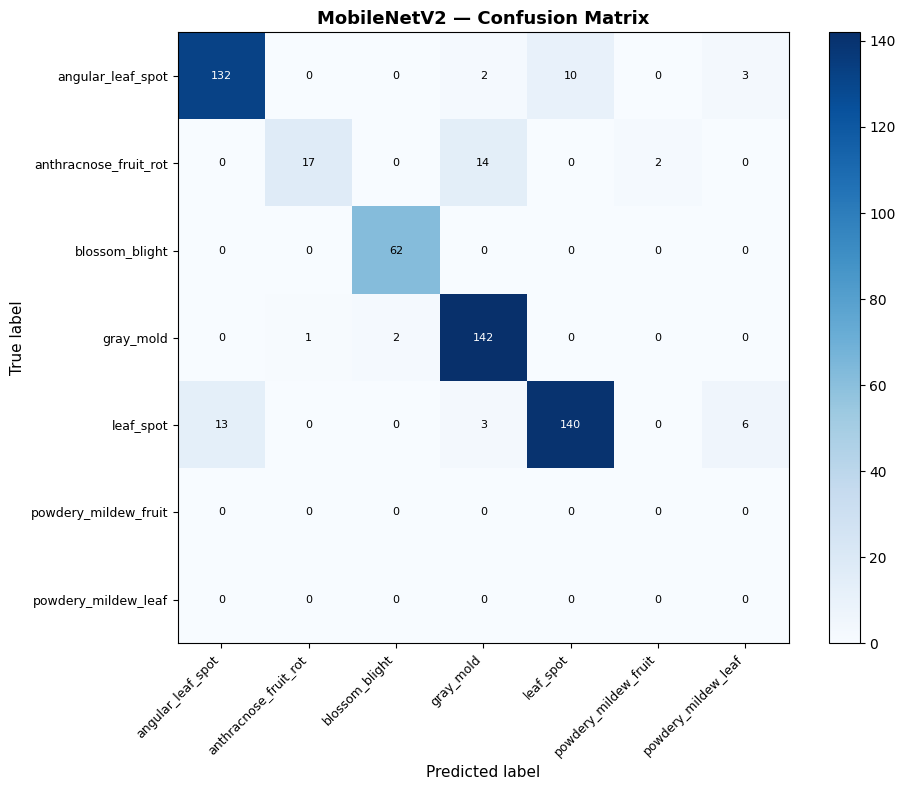

In [38]:
plot_history(mobilenet_history, title="MobileNetV2 Transfer Learning")
evaluate_model(mobilenet_model, CLASSES, "MobileNetV2", mobilenet_preprocess)

---
## Model D : ResNet50 Transfer Learning

ResNet50 introduced **skip connections (residual connections)** — one of the most  
important ideas in deep learning history (2015, Microsoft Research).

**Why it's powerful:**
- 50 layers deep — much deeper than VGG16 (16 layers)


In [39]:
# Reload batches with ResNet50 preprocessing
train_batches, val_batches, test_batches = get_batches(resnet_preprocess, augment=True)

def build_resnet_model(num_classes=7):
    base = tf.keras.applications.ResNet50(
        input_shape=(224, 224, 3),
        include_top=False,      # remove original 1000-class head
        weights="imagenet"
    )
    base.trainable = False      # freeze all base layers

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),  # better than Flatten for ResNet50
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ], name="ResNet50_TransferLearning")
    return model

resnet_model = build_resnet_model()
resnet_model.summary()

trainable = sum(np.prod(w.shape) for w in resnet_model.trainable_weights)
print(f"\nTrainable params: {trainable:,}")


Found 1450 images belonging to 7 classes.
Found 264 images belonging to 7 classes.
Found 549 images belonging to 7 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Trainable params: 263,175


In [40]:
resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_res = callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
)
lr_res = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, verbose=1
)

print("Training ResNet50...\n")
resnet_history = resnet_model.fit(
    train_batches,
    epochs=EPOCHS_TL,
    validation_data=val_batches,
    callbacks=[early_stop_res, lr_res],
    verbose=1,
)


Training ResNet50...

Epoch 1/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.6690 - loss: 1.0148 - val_accuracy: 0.8977 - val_loss: 0.3371 - learning_rate: 1.0000e-04
Epoch 2/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.8676 - loss: 0.4046 - val_accuracy: 0.9318 - val_loss: 0.2202 - learning_rate: 1.0000e-04
Epoch 3/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.9000 - loss: 0.2916 - val_accuracy: 0.9356 - val_loss: 0.1783 - learning_rate: 1.0000e-04
Epoch 4/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9241 - loss: 0.2230 - val_accuracy: 0.9356 - val_loss: 0.1607 - learning_rate: 1.0000e-04
Epoch 5/5
145/145 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9359 - loss: 0.1898 - val_accuracy: 0.9621 - val_loss: 0.1303 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 5.


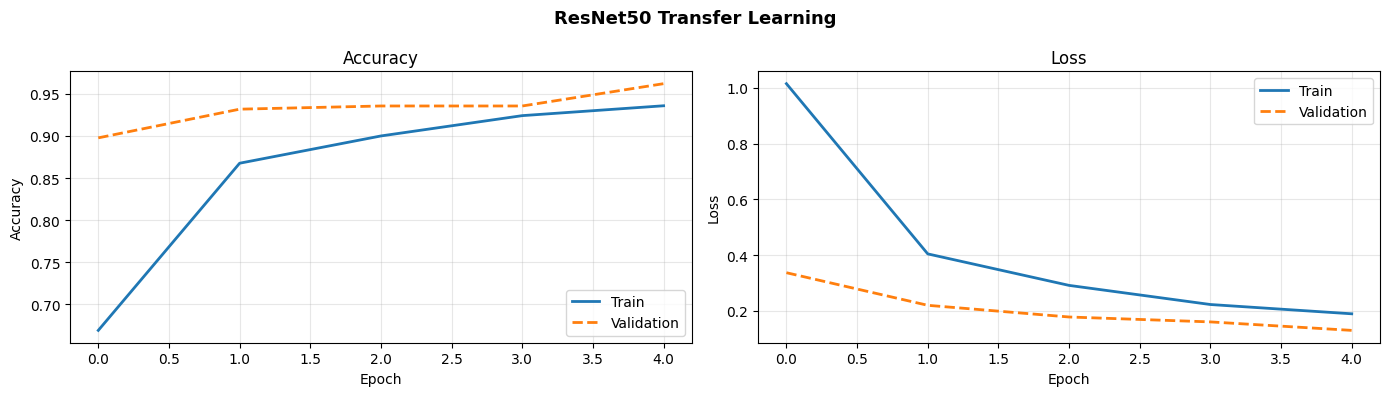

Found 549 images belonging to 7 classes.

  ResNet50 — Classification Report
                       precision    recall  f1-score   support

    angular_leaf_spot      0.844     0.959     0.898       147
anthracnose_fruit_rot      0.947     0.545     0.692        33
       blossom_blight      0.954     1.000     0.976        62
            gray_mold      0.885     0.959     0.921       145
            leaf_spot      0.946     0.759     0.842       162
 powdery_mildew_fruit      0.000     0.000     0.000         0
  powdery_mildew_leaf      0.000     0.000     0.000         0

             accuracy                          0.880       549
            macro avg      0.654     0.603     0.619       549
         weighted avg      0.904     0.880     0.884       549



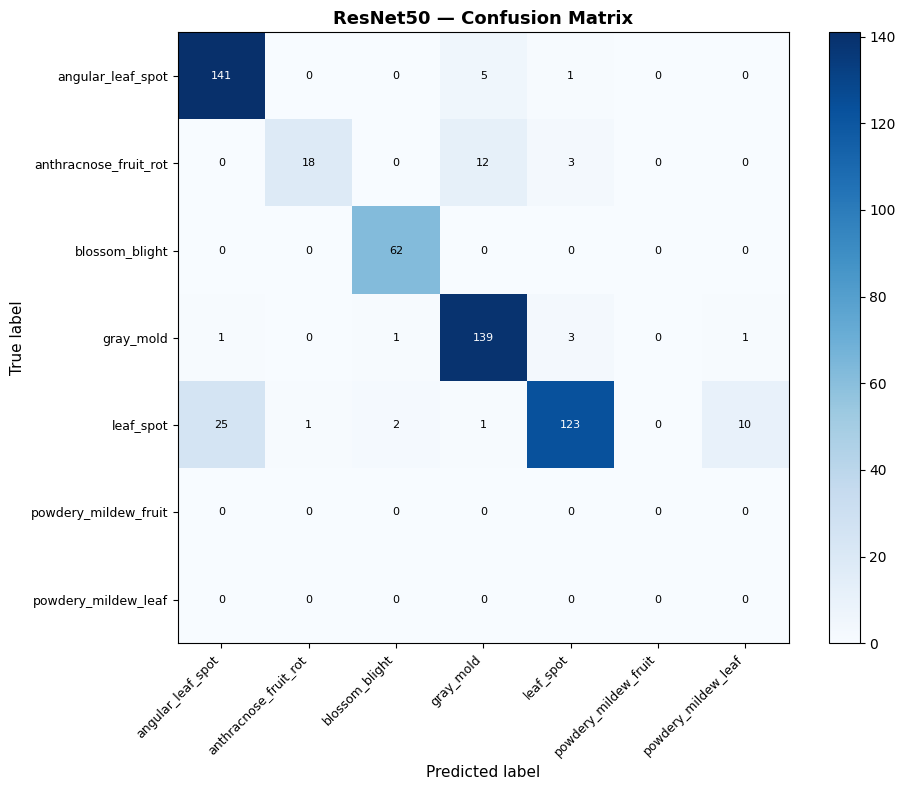

In [41]:
plot_history(resnet_history, title="ResNet50 Transfer Learning")
evaluate_model(resnet_model, CLASSES, title="ResNet50")


---
## Compare All 4 Models

Validation accuracy and loss for all models on the same graph.


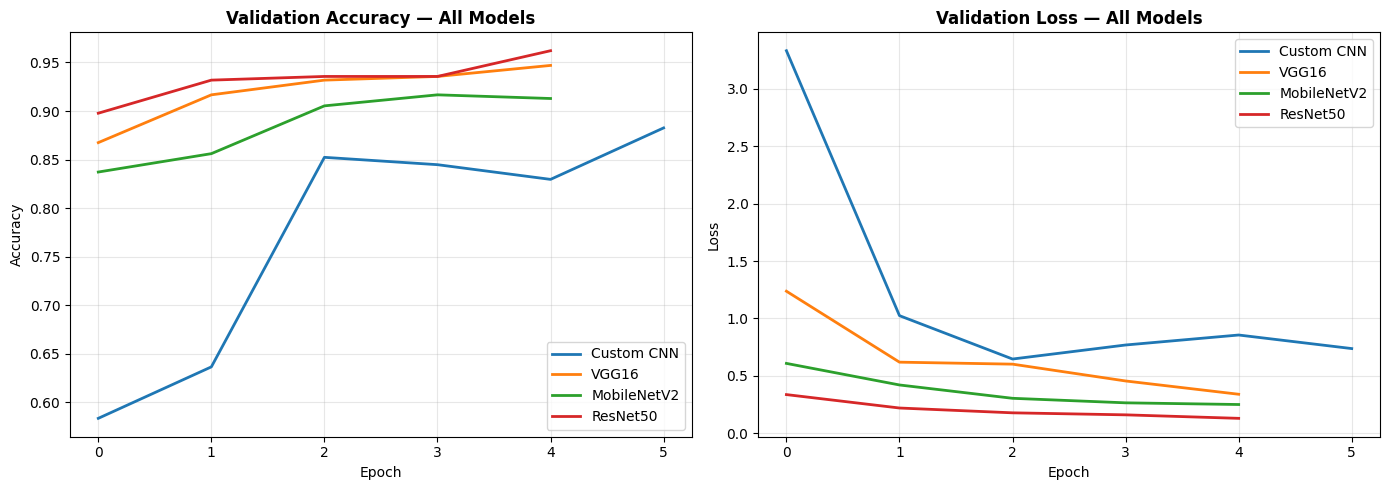


  Model                Val Accuracy       Val Loss
  Custom CNN                0.8826         0.7378
  VGG16                     0.9470         0.3400
  MobileNetV2               0.9129         0.2507
  ResNet50                  0.9621         0.1303


In [42]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for hist, label in [
    (cnn_history,       "Custom CNN"),
    (vgg_history,       "VGG16"),
    (mobilenet_history, "MobileNetV2"),
    (resnet_history,    "ResNet50"),
]:
    plt.plot(hist.history["val_accuracy"], label=label, linewidth=2)
plt.title("Validation Accuracy — All Models", fontweight="bold")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for hist, label in [
    (cnn_history,       "Custom CNN"),
    (vgg_history,       "VGG16"),
    (mobilenet_history, "MobileNetV2"),
    (resnet_history,    "ResNet50"),
]:
    plt.plot(hist.history["val_loss"], label=label, linewidth=2)
plt.title("Validation Loss — All Models", fontweight="bold")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*58)
print(f"  {'Model':<18} {'Val Accuracy':>14} {'Val Loss':>14}")
print("="*58)
for name, hist in [
    ("Custom CNN",   cnn_history),
    ("VGG16",        vgg_history),
    ("MobileNetV2",  mobilenet_history),
    ("ResNet50",     resnet_history),
]:
    acc  = hist.history["val_accuracy"][-1]
    loss = hist.history["val_loss"][-1]
    print(f"  {name:<18} {acc:>13.4f} {loss:>14.4f}")
print("="*58)


## Step 14 — Save the Trained Model

In [43]:
# Saving all trained models to Google Drive
vgg_model.save(MODEL_SAVE_PATH)
mobilenet_model.save(MODEL_SAVE_PATH.replace("vgg16", "mobilenetv2"))
resnet_model.save(MODEL_SAVE_PATH.replace("vgg16", "resnet50"))

print("✅ All models saved!")
print(f"  VGG16       : {MODEL_SAVE_PATH}")
print(f"  MobileNetV2 : {MODEL_SAVE_PATH.replace('vgg16', 'mobilenetv2')}")
print(f"  ResNet50    : {MODEL_SAVE_PATH.replace('vgg16', 'resnet50')}")



✅ All models saved!
  VGG16       : /content/drive/MyDrive/strawberry_vgg16.keras
  MobileNetV2 : /content/drive/MyDrive/strawberry_mobilenetv2.keras
  ResNet50    : /content/drive/MyDrive/strawberry_resnet50.keras


---

## 🧪 Step 15 — Upload Your Own Image & Get a Prediction

Upload any strawberry plant photo and see what disease the model detects.
The cell will:
1. Let you **choose a file** from your computer
2. Display the uploaded image
3. Run it through the **VGG16 model**
4. Show the **predicted disease** with confidence scores for all 7 classes


📤 Upload a strawberry plant image...


Saving strawberry image.jpg to strawberry image (2).jpg


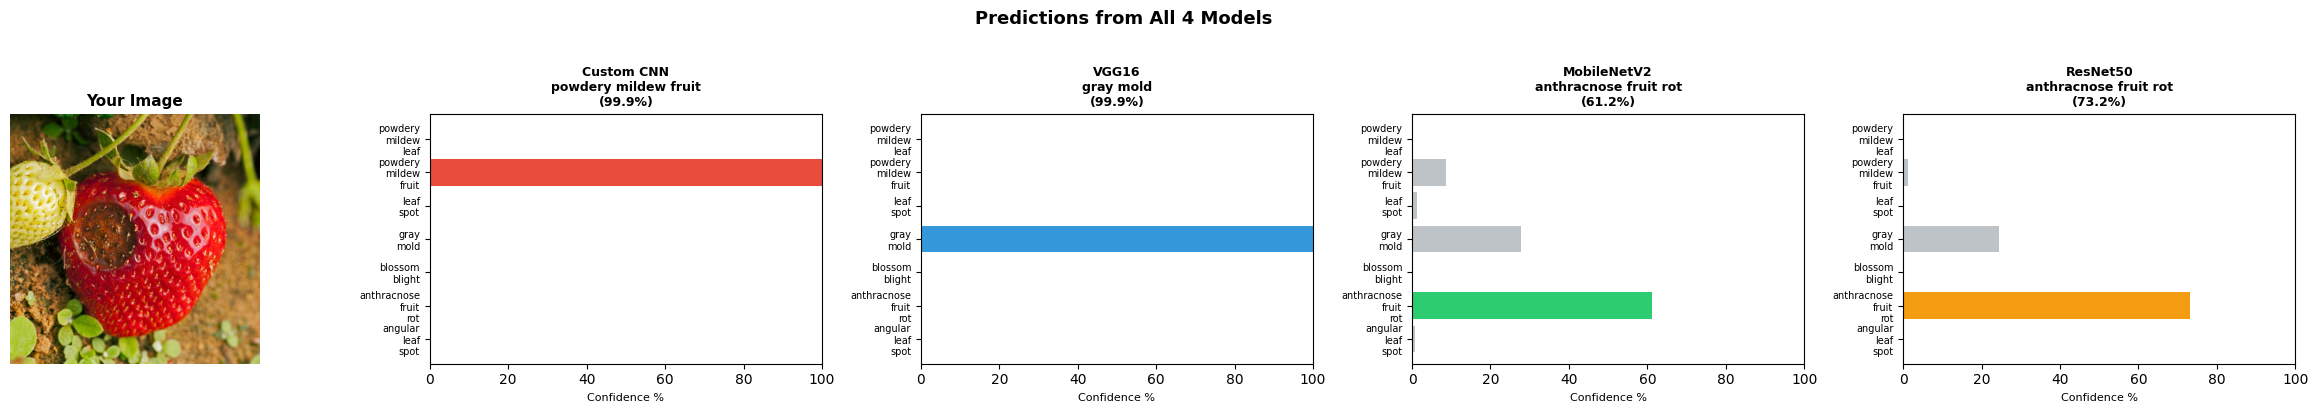


  Model              Prediction              Confidence
  Custom CNN         powdery_mildew_fruit         99.9%
  VGG16              gray_mold                    99.9%
  MobileNetV2        anthracnose_fruit_rot        61.2%
  ResNet50           anthracnose_fruit_rot        73.2%


In [49]:
from google.colab import files
from PIL import Image
import io

print("📤 Upload a strawberry plant image...")
uploaded = files.upload()

if uploaded:
    filename    = list(uploaded.keys())[0]
    img_pil     = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")
    img_resized = img_pil.resize((224, 224))
    img_array   = np.array(img_resized, dtype=np.float32)

    # Each model needs its own preprocessing
    models_to_test = {
        "Custom CNN":  (cnn_model,       vgg_preprocess),
        "VGG16":       (vgg_model,       vgg_preprocess),
        "MobileNetV2": (mobilenet_model, mobilenet_preprocess),
        "ResNet50":    (resnet_model,    resnet_preprocess),
    }

    results = {}
    for model_name, (model, preprocess_fn) in models_to_test.items():
        arr   = preprocess_fn(img_array.copy())
        arr   = np.expand_dims(arr, axis=0)
        preds = model.predict(arr, verbose=0)[0]
        top   = np.argmax(preds)
        results[model_name] = (CLASSES[top], preds[top] * 100, preds)

    # ── Display ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(24, 4))

    axes[0].imshow(img_pil)
    axes[0].set_title("Your Image", fontsize=11, fontweight="bold")
    axes[0].axis("off")

    palette = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
    for idx, (model_name, (pred_class, confidence, preds)) in enumerate(results.items()):
        ax = axes[idx + 1]
        bar_colors = [palette[idx] if i == np.argmax(preds) else "#bdc3c7"
                      for i in range(len(CLASSES))]
        short = [c.replace("_", "\n") for c in CLASSES]
        ax.barh(short, preds * 100, color=bar_colors)
        ax.set_xlim(0, 100)
        ax.set_title(
            f"{model_name}\n{pred_class.replace('_', ' ')}\n({confidence:.1f}%)",
            fontsize=9, fontweight="bold"
        )
        ax.set_xlabel("Confidence %", fontsize=8)
        ax.tick_params(axis="y", labelsize=7)

    plt.suptitle("Predictions from All 4 Models", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # ── Summary ──────────────────────────────────────────────────────────────
    print("\n" + "="*55)
    print(f"  {'Model':<18} {'Prediction':<23} {'Confidence':>10}")
    print("="*55)
    for model_name, (pred_class, confidence, _) in results.items():
        print(f"  {model_name:<18} {pred_class:<23} {confidence:>9.1f}%")
    print("="*55)

    if max(r[1] for r in results.values()) < 50:
        print("\n⚠️  Low confidence across all models.")
        print("    Try a clearer, well-lit image of the plant.")
